# Testing and Rapid Prototyping of Continuous and Ordinal Models

## Purpose: 

{TODO}

## Packages

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

import polars as pl 

_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(100000)
_=pl.Config.set_tbl_width_chars(10000)

import glob, importlib, yaml, numpy

import matplotlib.pyplot as plt

%load_ext autoreload 
%autoreload 2
    
YogiModelRunner = getattr(
    importlib.import_module("1_yogi_model_runner"),
    "YogiModelRunner"
)


## Literals

In [2]:
with open("params.yaml", 'r') as file: 
    params = yaml.safe_load(file)

params

{'dataset': {'cell_lines': ['K562', 'HepG2'],
  'distances': [50, 100, 150, 200, 250, 500],
  'control_only': [False, True],
  'psi_subsets': [None, [0, 1], [0.1, 0.9]],
  'read_count_quantiles': [None, 0.1, 0.2, 0.4],
  'data_flavors': ['binary', 'num_peaks', 'rbp_exp', 'rbp_exp_peak'],
  'count_normalization_methods': ['getmm', 'tmm'],
  'log_counts': [False, True]},
 'modeling': {'models': ['OLSRegression',
   'ElasticNetContinuous',
   'OLSOrdinalRegression',
   'ElasticNetOrdinal',
   'OrdinalGBT'],
  'random_states': [17, 97],
  'ordinal_regression_method': ['logit', 'probit'],
  'data_splitting_method': 'gene',
  'train_split': 0.7,
  'test_split': 0.15,
  'validate_split': 0.15,
  'alpha': [0.001, 0.01, 0.1, 1, 10],
  'l1_ratio': [0, 0.2, 0.4, 0.6, 0.8, 1]},
 'SLURM': {'plots_folder': '../output/plots/'}}

2024-10-21 19:32:10.243 | INFO     | 1_yogi_model_runner:__post_init__:33 - Loaded configuration: 
dataset:
  cell_line: K562
  distance: 100
  control_only: false
  psi_subset: null
  read_count_quantile: null
  data_flavor: binary
  count_normalization_method: tmm
  log_counts: false
modeling:
  model: OLSRegression
  random_state: 17
  data_splitting_method: gene
  train_split: 0.7
  test_split: 0.15
  validate_split: 0.15
SLURM:
  plots_folder: ../output/plots/



2024-10-21 19:32:11.683 | INFO     | 1_yogi_model_runner:load_data:111 - Lazy loading dataset for downstream parallel filtering...
2024-10-21 19:32:24.529 | INFO     | 1_yogi_model_runner:load_data:142 - Finished filtering steps and gathered dataframe in-memory
2024-10-21 19:32:24.533 | INFO     | 1_yogi_model_runner:load_data:143 - Converting data to '''binary''' data flavor
2024-10-21 19:32:24.535 | INFO     | 1_yogi_model_runner:cast_column_data_types:90 - Converting columns to appropriate data types for binary data flavor
Converting each RBP KD Target's corresponding columns to '0' (e.g. 'RBFOX2 KD' means all 'RBFOX2 feature column' values are set to 0).: 100%|██████████| 2/2 [00:00<00:00, 383.02it/s]
2024-10-21 19:32:24.711 | SUCCESS  | 1_yogi_model_runner:load_data:207 - Data loaded successfully for K562 with window size 100 with shape: (10000, 623)
2024-10-21 19:32:24.712 | INFO     | 1_yogi_model_runner:split_data:211 - Splitting data into training testing, and validation sets


test_mean_absolute_error,▁
test_mean_squared_error,▁
test_median_absolute_error,▁
test_r2_score,▁
test_root_mean_squared_error,▁
train_mean_absolute_error,▁
train_mean_squared_error,▁
train_median_absolute_error,▁
train_r2_score,▁
train_root_mean_squared_error,▁
validate_mean_absolute_error,▁


2024-10-21 19:32:28.142 | SUCCESS  | 1_yogi_model_runner:__post_init__:56 - COMPLETED SUCCESSFULLY: OLSRegression for K562 with window size 100


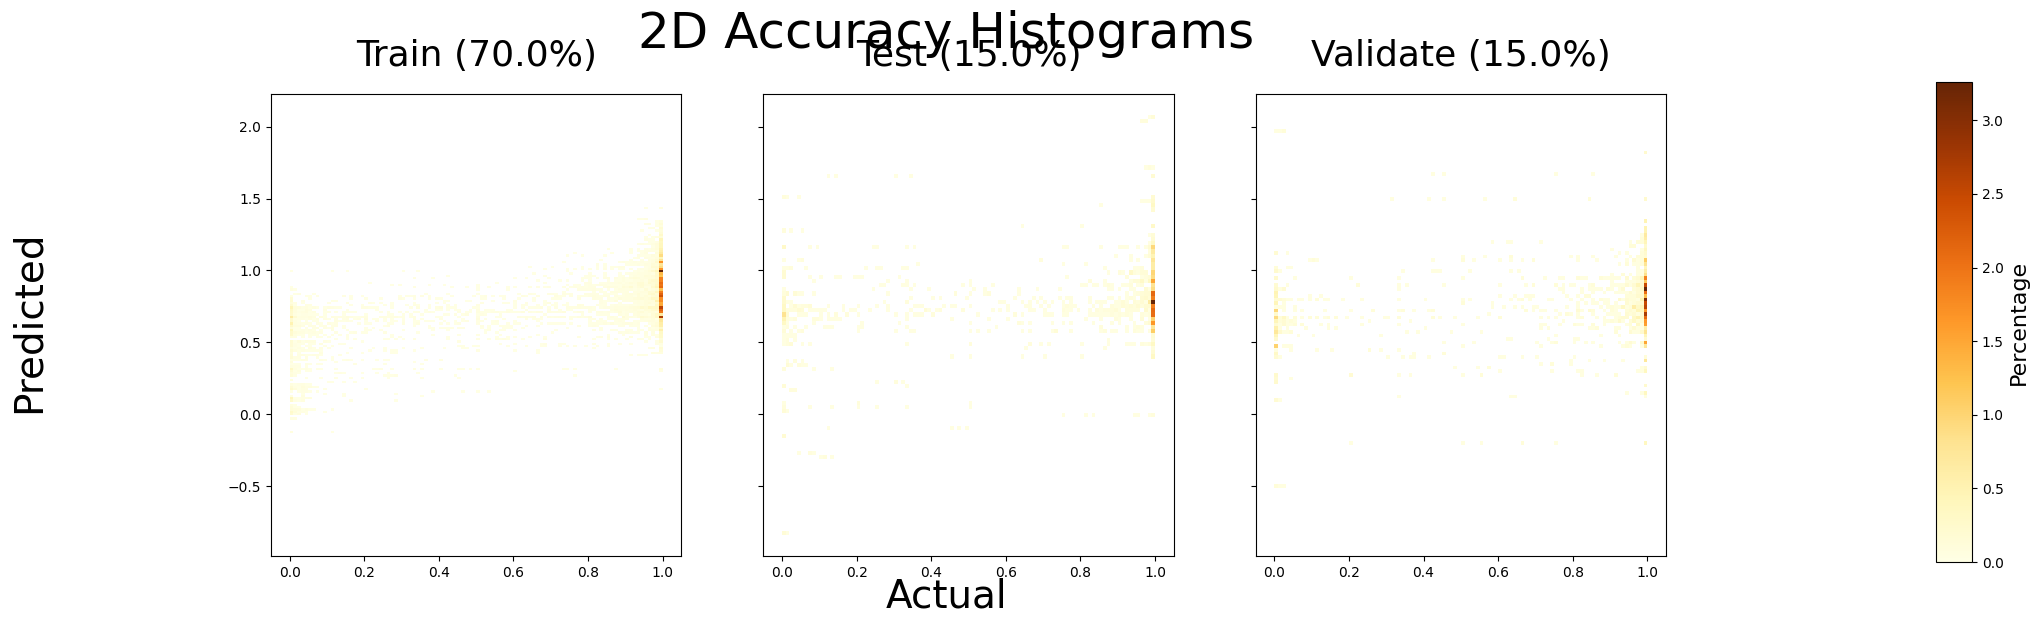

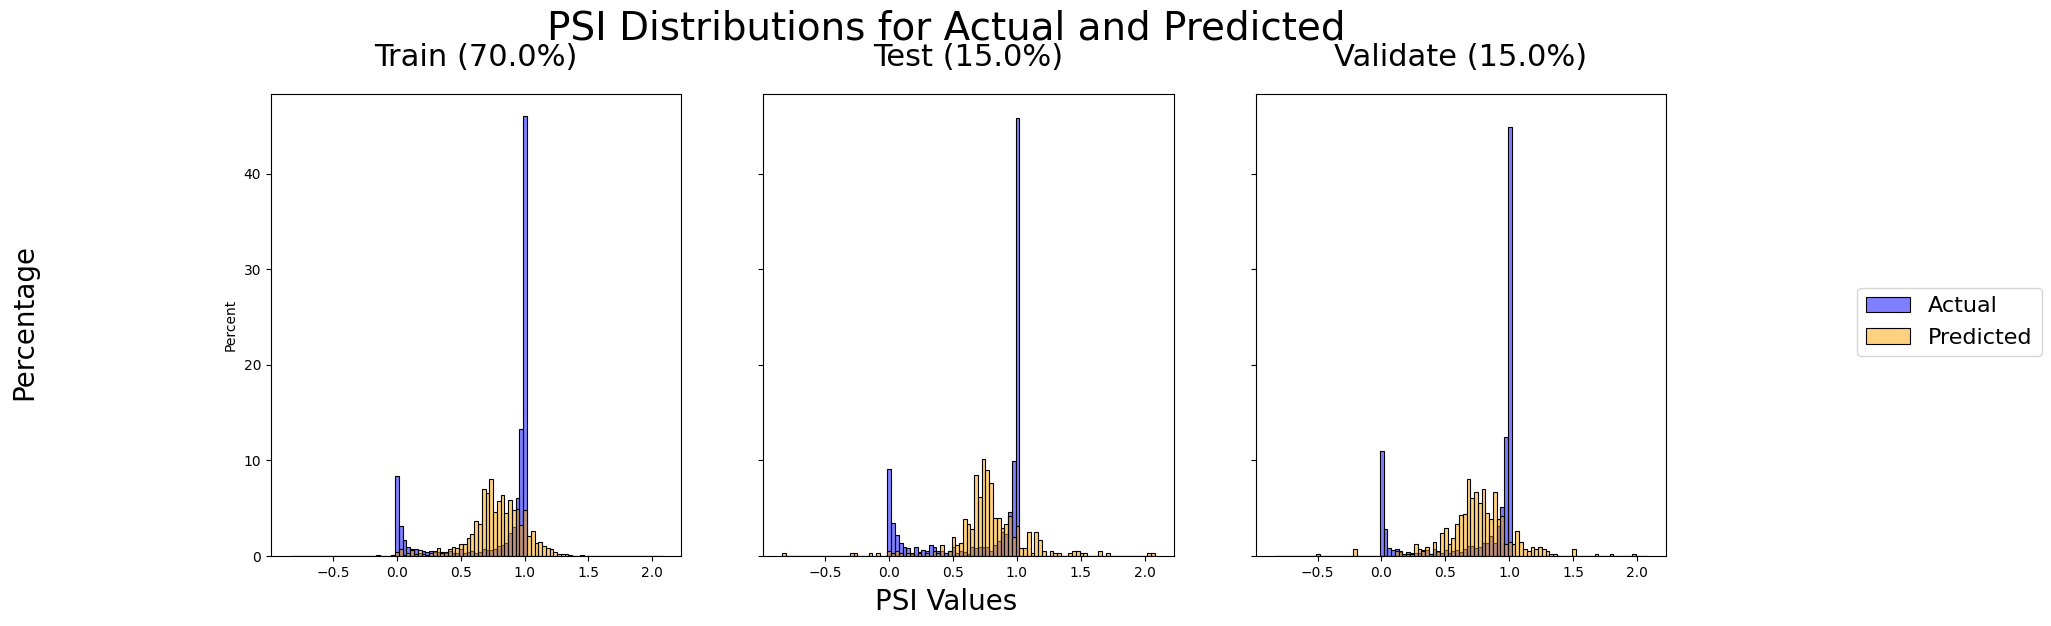

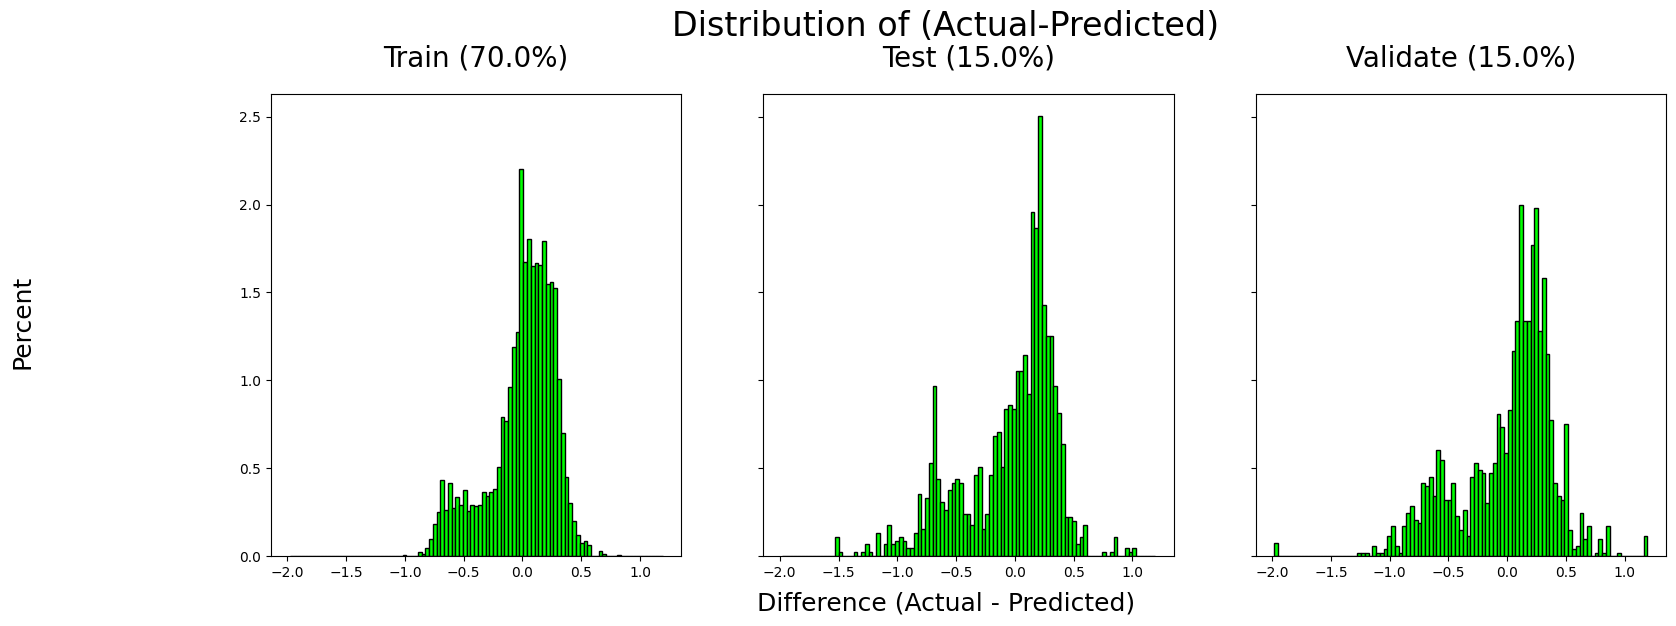

In [6]:
modeler = YogiModelRunner(
    yaml_file_path = "test_params.yaml", 
    wandb_project_name = "yogi-OLS-baseline-regression"
)

In [ ]:
for cell_line in ["K562","HepG2"]:
    for distance in [100,10000]:
    
        df = pl.scan_csv(
            f"../../3_create_RBP_ML_input/4_create_num_peaks_ML_input/final_modeling_input_datasets/{cell_line}_{distance}_num-peaks-no-kd.tsv.gz", 
            separator="\t"
        ).select(["Target_PSI", "Gene Name"])

        result = df.group_by("Gene Name").agg([
            pl.col("Target_PSI").mean().alias("mean_Target_PSI"),
            pl.col("Target_PSI").std().alias("std_Target_PSI")
        ])
        
        # Collect the result into a DataFrame
        result_df = result.collect(streaming=True)

        # Create a figure with 2 subplots for mean and std
        fig, axs = plt.subplots(2, 2, figsize=(12, 4), dpi=200)
        
        # Boxplot for mean_Target_PSI
        _=axs[0, 0].boxplot(result_df['mean_Target_PSI'])
        _=axs[0, 0].set_title('Boxplot of Mean Target PSI')
        
        # Histogram for mean_Target_PSI
        _=axs[0, 1].hist(result_df['mean_Target_PSI'], bins=100, edgecolor='black')
        _=axs[0, 1].set_title('Histogram of Mean Target PSI')
        
        # Boxplot for std_Target_PSI
        _=axs[1, 0].boxplot(result_df['std_Target_PSI'])
        _=axs[1, 0].set_title('Boxplot of Std Target PSI')
        
        # Histogram for std_Target_PSIr
        _=axs[1, 1].hist(result_df['std_Target_PSI'], bins=100, edgecolor='black')
        _=axs[1, 1].set_title('Histogram of Std Target PSI')

        _=fig.suptitle(f"{cell_line} {distance}")
        
        # Adjust layout
        plt.tight_layout()
        plt.show()